In [61]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
from statsmodels.tsa.seasonal import seasonal_decompose


In [43]:
# Set plot style
sns.set(style="whitegrid")

EDA of Breakfast Data: data_breakfast_with_coordinates

In [44]:
# Load your dataset
dfb = pd.read_csv('raw_data/data_breakfast_with_coordinates.csv')
dfb.head()

C:\Users\kaoji\AppData\Local\Temp\ipykernel_18120\93970611.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfb = pd.read_csv('raw_data/data_breakfast_with_coordinates.csv')


,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,...,FNS Area,Level,FCPS Region,CEP Schools,Original_School_Name_excel,Normalized_School_Name_excel,address,zipcode,latitude,longitude
0,Aldrin Elementary,5/01/2025,10041,Mini Maple Pancakes (Package),57,0,57,59,56,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
1,Aldrin Elementary,5/01/2025,20001,1% White Milk (Each),33,0,33,37,34,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
2,Aldrin Elementary,5/01/2025,20017,Orange (6 Slices per 1/2 cup),51,0,51,55,53,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
3,Aldrin Elementary,5/01/2025,20038,Fat Free White Milk (Each),11,0,11,15,13,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
4,Aldrin Elementary,5/01/2025,30003,Honey Cheerios Cereal (Each),10,0,10,10,7,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806


In [45]:
# Show basic info
print("Shape of dataset:", dfb.shape)
print("\nData types:\n", dfb.dtypes)

Shape of dataset: (54783, 36)

Data types:
 School_Name                      object
Date                             object
Identifier                       object
Name                             object
Planned_Reimbursable              int64
Planned_Non-Reimbursable          int64
Planned_Total                     int64
Offered_Reimbursable              int64
Offered_Non-Reimbursable          int64
Offered_Total                     int64
Served_Reimbursable               int64
Served_Non-Reimbursable          object
Served_Total                      int64
Discarded_Total                  object
Discarded_Cost                   object
Subtotal_Cost                    object
Left_Over_Total                   int64
Left_Over_Percent_of_Offered     object
Left_Over_Cost                   object
Production_Cost_Total            object
Original_School_Name_csv         object
Normalized_School_Name_csv       object
Mapped_Normalized_Name           object
School Name                      obj

In [46]:
# show statistics
dfb.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total,School ID,FNS Area,zipcode,latitude,longitude
count,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,54783.000000,43091.000000,54783.000000,54783.000000
mean,33.075991,0.082580,33.158571,44.757425,35.055419,0.506106,35.561525,0.127010,9.070076,221.570688,5.487688,21678.367849,38.846138,-77.255404
std,62.696781,1.050133,62.741879,67.639075,58.638979,3.274645,58.787670,1.019526,21.146098,130.689822,2.855518,836.748781,0.074699,0.106912
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,1.000000,20120.000000,38.684824,-77.485556
25%,3.000000,0.000000,3.000000,10.000000,5.000000,0.000000,6.000000,0.000000,0.000000,106.000000,3.000000,22003.000000,38.790261,-77.339445
50%,14.000000,0.000000,14.000000,24.000000,16.000000,0.000000,17.000000,0.000000,3.000000,207.000000,5.000000,22042.000000,38.843720,-77.241318
75%,39.000000,0.000000,40.000000,50.000000,40.000000,0.000000,41.000000,0.000000,10.000000,333.000000,8.000000,22152.000000,38.900921,-77.181019
max,4561.000000,63.000000,4561.000000,2245.000000,2216.000000,165.000000,2216.000000,53.000000,985.000000,501.000000,10.000000,23305.000000,39.041851,-77.047536


In [47]:
# Check for missing values
print("\nMissing values:\n", dfb.isnull().sum())


Missing values:
 School_Name                         0
Date                                0
Identifier                          0
Name                                0
Planned_Reimbursable                0
Planned_Non-Reimbursable            0
Planned_Total                       0
Offered_Reimbursable                0
Offered_Non-Reimbursable            0
Offered_Total                       0
Served_Reimbursable                 0
Served_Non-Reimbursable             0
Served_Total                        0
Discarded_Total                     0
Discarded_Cost                      0
Subtotal_Cost                       0
Left_Over_Total                     0
Left_Over_Percent_of_Offered        0
Left_Over_Cost                      0
Production_Cost_Total               0
Original_School_Name_csv            0
Normalized_School_Name_csv          0
Mapped_Normalized_Name              0
School Name                         0
School ID                           0
Distribution Kitchen (DK)       

In [48]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfb.duplicated().sum())


Number of duplicate rows: 0


In [49]:
# overview look at food names
food_cat = dfb.groupby('Name')['Planned_Total'].sum()

summary_b = food_cat.sort_values(ascending=False)
sumb_10 = summary_b.head(10
)
print(sumb_10)

Name
Apple Juice (Each)                                     443084
Orange Tangerine Juice (Each)                          243280
1% White Milk (Each)                                   202199
Mini Maple Pancakes (Package)                          135930
Red Delicious Apple (Each - serving)                    86029
Honey Cheerios Cereal (Each)                            74201
Cinnamon Toast Crunch Cereal, 25% Less Sugar (Each)     70678
Cinnamon Chex Cereal (Each)                             67069
Fat Free White Milk (Each)                              62881
Blueberry Chex Cereal (Each)                            58812
Name: Planned_Total, dtype: int64


EDA of Lunch Data: data_lunch_with_coordinates

In [50]:
# Load your dataset
dfl = pd.read_csv('raw_data/data_lunch_with_coordinates.csv')
dfl.head()

C:\Users\kaoji\AppData\Local\Temp\ipykernel_18120\2345536583.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  dfl = pd.read_csv('raw_data/data_lunch_with_coordinates.csv')


,School_Name,Date,Identifier,Name,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,...,FNS Area,Level,FCPS Region,CEP Schools,Original_School_Name_excel,Normalized_School_Name_excel,address,zipcode,latitude,longitude
0,Aldrin Elementary,5/01/2025,10044,Soft Pretzel (1 pretzel),15,0,15,31,27,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
1,Aldrin Elementary,5/01/2025,10062,Corn (1/4 cup (thawed)),92,0,92,155,152,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
2,Aldrin Elementary,5/01/2025,20001,1% White Milk (Each),44,0,44,120,43,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
3,Aldrin Elementary,5/01/2025,20002,Fat Free Chocolate Milk (Each),133,0,133,155,131,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806
4,Aldrin Elementary,5/01/2025,20016,String Cheese (Each),2,0,2,5,2,0,...,4,ES,Region 1,NaN,Aldrin ES,aldrin es,"11375 Center Harbor Rd, Reston, VA 20194",20194.0,38.979865,-77.337806


In [51]:
# Show basic info
print("Shape of dataset:", dfl.shape)
print("\nData types:\n", dfl.dtypes)

Shape of dataset: (134073, 36)

Data types:
 School_Name                      object
Date                             object
Identifier                       object
Name                             object
Planned_Reimbursable              int64
Planned_Non-Reimbursable          int64
Planned_Total                     int64
Offered_Reimbursable              int64
Offered_Non-Reimbursable          int64
Offered_Total                     int64
Served_Reimbursable               int64
Served_Non-Reimbursable          object
Served_Total                      int64
Discarded_Total                  object
Discarded_Cost                   object
Subtotal_Cost                    object
Left_Over_Total                   int64
Left_Over_Percent_of_Offered     object
Left_Over_Cost                   object
Production_Cost_Total            object
Original_School_Name_csv         object
Normalized_School_Name_csv       object
Mapped_Normalized_Name           object
School Name                      ob

In [52]:
# show statistics
dfl.describe()

,Planned_Reimbursable,Planned_Non-Reimbursable,Planned_Total,Offered_Reimbursable,Offered_Non-Reimbursable,Offered_Total,Served_Reimbursable,Served_Total,Left_Over_Total,School ID,FNS Area,zipcode,latitude,longitude
count,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,134073.000000,108035.000000,134073.000000,134073.000000
mean,60.198258,0.637600,60.835858,87.234268,70.530293,2.398164,72.928457,0.544025,13.765359,218.289044,5.501436,21703.038737,38.845037,-77.252795
std,204.915803,9.087729,205.433251,178.069371,163.365598,15.088872,164.125179,3.517075,43.784457,129.816095,2.882849,822.466617,0.073477,0.106562
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,1.000000,20120.000000,38.684824,-77.485556
25%,0.000000,0.000000,0.000000,13.000000,6.000000,0.000000,9.000000,0.000000,0.000000,104.000000,3.000000,22003.000000,38.787321,-77.328915
50%,20.000000,0.000000,20.000000,42.000000,30.000000,0.000000,32.000000,0.000000,1.000000,203.000000,5.000000,22043.000000,38.843581,-77.240787
75%,70.000000,0.000000,70.000000,100.000000,87.000000,0.000000,90.000000,0.000000,10.000000,327.000000,8.000000,22152.000000,38.896115,-77.174869
max,54100.000000,500.000000,54100.000000,40030.000000,39957.000000,630.000000,39957.000000,525.000000,1286.000000,501.000000,10.000000,23305.000000,39.041851,-77.047536


In [53]:
# Check for missing values
print("\nMissing values:\n", dfl.isnull().sum())


Missing values:
 School_Name                          0
Date                                 0
Identifier                           0
Name                                 0
Planned_Reimbursable                 0
Planned_Non-Reimbursable             0
Planned_Total                        0
Offered_Reimbursable                 0
Offered_Non-Reimbursable             0
Offered_Total                        0
Served_Reimbursable                  0
Served_Non-Reimbursable              0
Served_Total                         0
Discarded_Total                      0
Discarded_Cost                       0
Subtotal_Cost                        0
Left_Over_Total                      0
Left_Over_Percent_of_Offered         0
Left_Over_Cost                       0
Production_Cost_Total                0
Original_School_Name_csv             0
Normalized_School_Name_csv           0
Mapped_Normalized_Name               0
School Name                          0
School ID                            0
Distrib

In [54]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfl.duplicated().sum())


Number of duplicate rows: 0


In [55]:
# overview look at food names
food_cat = dfl.groupby('Name')['Planned_Total'].sum()

summary_l = food_cat.sort_values(ascending=False)
suml_10 = summary_l.head(10
)
print(suml_10)

Name
Fat Free Chocolate Milk (Each)          948793
Lettuce Blend Salad Mix (1/2 cup)       610651
Ketchup Packet (Packet)                 599150
Ranch Dressing (1 ounce)                356475
PB&J Power Pack (Power Packs)           333876
1% White Milk (Each)                    242109
Manager's Vegetable Choice (1/4 cup)    229858
Cheese Pizza (Slice)                    195804
Mayonnaise Packet (Packet)              193356
Chicken Tenders (3 tenders)             172073
Name: Planned_Total, dtype: int64


EDA of Sales

In [56]:
# Load your dataset
dfs = pd.read_csv('raw_data/sales.csv')
dfs.head()

,time_of_day,school_code,school_name,date,item,description,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
0,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,1146,CEREAL MEAL,19,3,0,16,0,0,0,0,0,0,0,0,0
1,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,1164,BAGEL W/CREAM CHEESE,6,0,0,6,0,0,0,0,0,0,0,0,0
2,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,1310,ALC BREAKFAST ENTREE,11,0,0,0,0,11,0,0,0,0,0,0,0
3,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,151,CEREAL/ NO MILK,13,0,0,0,0,13,0,0,0,0,0,0,0
4,breakfast,17,COLVIN_RUN_ELEMENTARY,03/03/2025,188,$1.00 WATER 16.9oz,1,0,0,0,0,1,0,0,0,0,0,0,0


In [57]:
# Show basic info
print("Shape of dataset:", dfs.shape)
print("\nData types:\n", dfs.dtypes)

Shape of dataset: (224536, 19)

Data types:
 time_of_day            object
school_code             int64
school_name            object
date                   object
item                    int64
description            object
total                   int64
free_meals              int64
reduced_price_meals     int64
full_price_meals        int64
adults                  int64
alac_student            int64
alac_adult              int64
earned_student          int64
earned_adult            int64
earned_alac_student     int64
earned_alac_adult       int64
adj_alac                int64
adj_meal                int64
dtype: object


In [58]:
# show statistics
dfs.describe()

,school_code,item,total,free_meals,reduced_price_meals,full_price_meals,adults,alac_student,alac_adult,earned_student,earned_adult,earned_alac_student,earned_alac_adult,adj_alac,adj_meal
count,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.000000,224536.0
mean,221.613398,1245.693274,40.621615,15.044964,1.497666,11.708799,0.137043,12.225830,0.096283,0.001038,0.303288,0.003643,0.000334,0.000013,0.0
std,133.682146,909.230796,69.212535,40.143932,5.621533,27.997202,2.062739,41.665041,0.954267,0.052410,1.239649,0.189640,0.023019,0.003655,0.0
min,17.000000,1.000000,0.000000,-3.000000,-1.000000,-18.000000,0.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,103.000000,717.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,206.000000,1136.000000,14.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,334.000000,1310.000000,46.000000,11.000000,1.000000,11.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
max,501.000000,3501.000000,955.000000,942.000000,801.000000,649.000000,267.000000,947.000000,43.000000,9.000000,37.000000,25.000000,5.000000,1.000000,0.0


In [59]:
# Check for missing values
print("\nMissing values:\n", dfs.isnull().sum())


Missing values:
 time_of_day            0
school_code            0
school_name            0
date                   0
item                   0
description            0
total                  0
free_meals             0
reduced_price_meals    0
full_price_meals       0
adults                 0
alac_student           0
alac_adult             0
earned_student         0
earned_adult           0
earned_alac_student    0
earned_alac_adult      0
adj_alac               0
adj_meal               0
dtype: int64


In [60]:
# Check for duplicates
print("\nNumber of duplicate rows:", dfs.duplicated().sum())


Number of duplicate rows: 0


In [63]:
# Convert your datetime column
dfs['date'] = pd.to_datetime(dfs['date']) 

# Set datetime as index
dfs.set_index('date', inplace=True)

# Sort by date
dfs = dfs.sort_index()


In [64]:
# Check date range and frequency
print("Date Range:", dfs.index.min(), "to", dfs.index.max())
print("Frequency (inferred):", pd.infer_freq(dfs.index))

Date Range: 2025-03-03 00:00:00 to 2025-05-30 00:00:00
Frequency (inferred): None


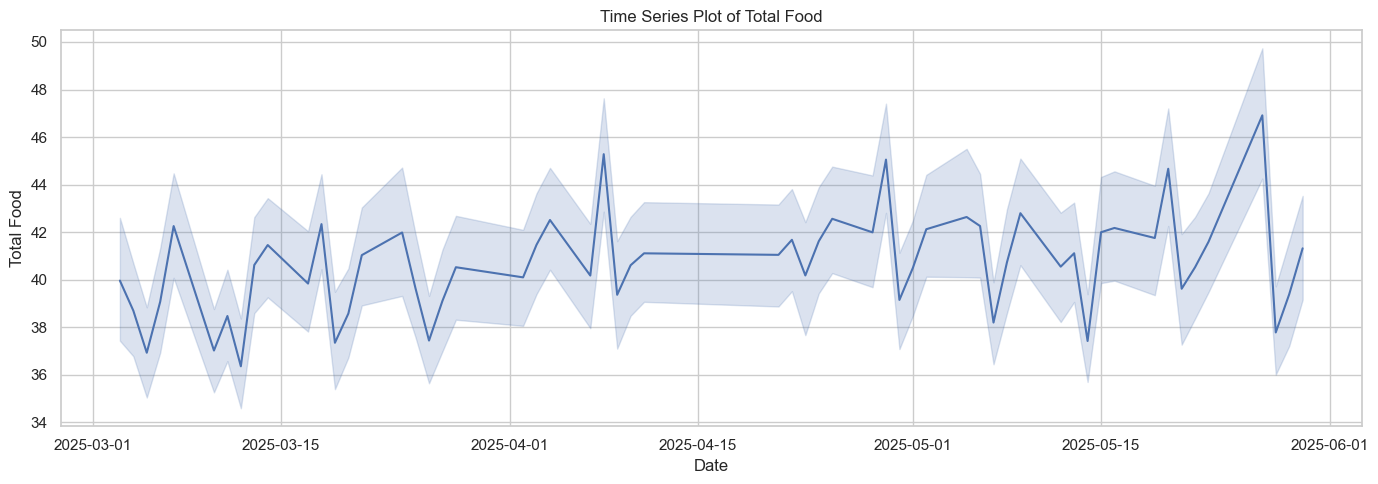

In [66]:
# Plot full time series for a numeric column
plt.figure(figsize=(14, 5))
sns.lineplot(data=dfs, x=dfs.index, y='total')
plt.title("Time Series Plot of Total Food")
plt.xlabel("Date")
plt.ylabel("Total Food")
plt.tight_layout()
plt.show()